In [1]:
import os
import os.path as op

import numpy as np
from scipy.stats import pearsonr

import nibabel as nib
from nilearn import datasets, image

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap
from seaborn import kdeplot

import networkx as nx
from sklearn.cluster import KMeans

import importlib

import dgsp
import palettes
import bimod_plots as plot

import clustering as e_clust
import graph_plot as g_plot

import data_load as dload
import bundle as b_utils

In [2]:
# CopyPasted from utils.py in other repo:
import pickle

def save(pickle_filename: str, iterable: object) -> None:
    """
    Pickle an object to a file.

    Parameters
    ----------
    pickle_filename : str
        Path to the file where the object will be pickled.
    iterable : object
        The object to be pickled.

    Returns
    -------
    None
    """
    with open(pickle_filename, "wb") as handle:
        pickle.dump(iterable, handle, protocol=pickle.HIGHEST_PROTOCOL)


def load(pickle_filename: str) -> object:
    """
    Load a pickled object from the specified file.

    Parameters
    ----------
    pickle_filename : str
        The filename of the pickled object to load.

    Returns
    -------
    object
        The loaded object.
    """
    with open(pickle_filename, "rb") as handle:
        b = pickle.load(handle)
    return b

In [3]:
import sys
path_to_effective = "../../effectivedelay_estimation"
sys.path.append(path_to_effective)

from src import regmod
from src import utils
from src import solver

path_to_ressources = op.join(path_to_effective, "resources")
path_to_data = "/Users/acionca/data"
path_to_ec = "./results/atlas_correspondence"

path_to_mstruct = "/Users/acionca/data/microstructure_connectomes_HCP_3T"
path_to_lobe = "./results/atlas_correspondence"

path_to_benchmark = "/Users/acionca/code/dGSP/dSVD/results/BrainKmeans"

dict_keys(['cluster_palette', 'cluster_palette_cb', 'cluster_palette_soft', 'div_rb', 'extended_ncar'])


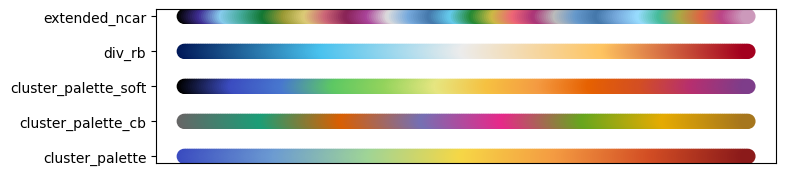

In [4]:
importlib.reload(palettes)
importlib.reload(plot)

cmaps = plot.get_all_cmaps()
print(cmaps.keys())

There are 141 nodes in the graph
54.08% of connections remain  after thresholding


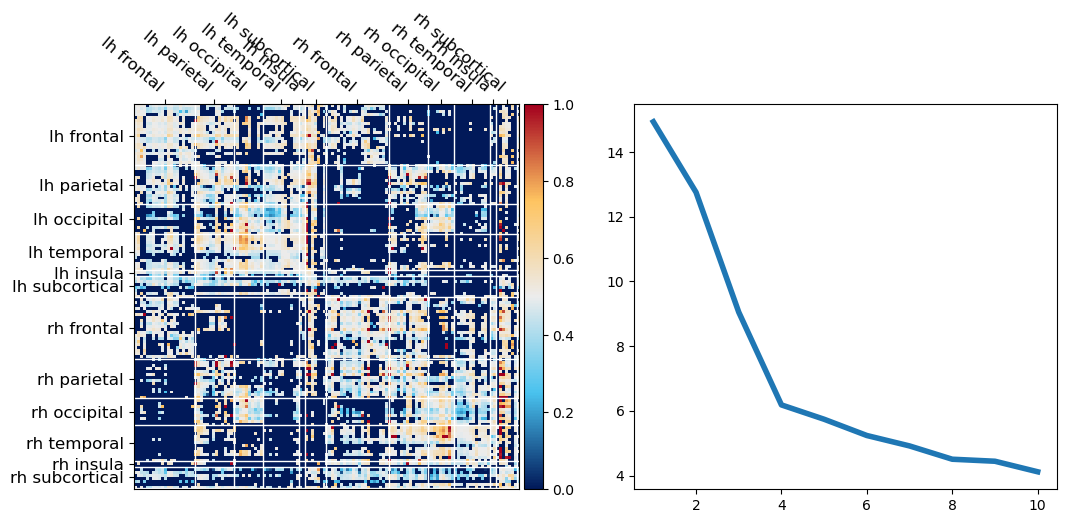

In [5]:
importlib.reload(dload)
importlib.reload(dgsp)
importlib.reload(b_utils)
importlib.reload(plot)

all_scales = [1, 2, 3, 4]

use_delay = False
k_threshold = 0
b_thresh = 0
slines_theshold = 5

struct_type = ""

scale = 2

k_matrix, labels, node_centers = dload.load_bundle_graph(path_to_data=path_to_ressources,
                                                         data_suffix="Laus2018_",
                                                         scale=scale,
                                                         b_prob_threshold=0,
                                                         slines_theshold=slines_theshold,
                                                         log_slines=False,
                                                         normalize_slines=False,
                                                         verbose=True)

_, node_centers = b_utils.fix_thalamus(labels, pos=node_centers)
labels, k_matrix = b_utils.fix_thalamus(labels, matrix=k_matrix)
k_matrix[k_matrix < b_thresh] = 0

# ec_data = dload.load(op.join(path_to_ec, f"Laus2018_EffConnFromSch414-scale{scale}.pkl"))
# ec_data = dload.load(op.join(path_to_ec, f"Laus2018_EffConnFromSch414-scale{scale}OneThal.pkl"))
# ec_mat = ec_data["conv"]
# # print(f"Removing {np.sum(ec_mat < 0)/ec_mat.size*100:.2f}% negative weights from EC matrix")
# ec_mat[ec_mat < 0] = 0

ec_mat = dload.get_ec_data(scale=scale, path_to_ec=path_to_ec, remove_neg=True, fix_thal=True)

# labels = b_utils.fix_thalamus(labels, matrix=None)

gamma = 1
ec_mat = ec_mat ** gamma
dir_ratio = np.divide(ec_mat, (ec_mat + ec_mat.T),
                      where=(ec_mat + ec_mat.T) > 0,
                      out=np.zeros_like(ec_mat))
graph = (k_matrix > 0) * dir_ratio

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
V = Vh.T

n_nodes = len(S)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

order_by_lobe, lobe_sizes, lobe_labels, lobe_df = dload.get_lobe_info(scale, labels, path_to_lobe=path_to_lobe)

axes[0].imshow(graph[order_by_lobe][:, order_by_lobe], cmap=cmaps["div_rb"], interpolation="none")
plot.add_cbar(fig ,axes[0])
plot.plot_lobe_lines(axes[0], lobe_sizes, lobe_labels)

nshow = 10
axes[1].plot(np.arange(nshow)+1, S[:nshow], lw=4, zorder=0)

In [6]:
importlib.reload(dgsp)

scale = 2
gamma = 2
n_vec_max = 20
# n_vec_max = 5
scale_factor = S[:n_vec_max] ** 2

n_trials = 50
n_init = 50
dthresh = 0
selected_sort = 0

# all_n_kmeans = np.arange(10, 250, 5)
# all_n_kmeans = np.arange(10, 100, 1)
all_n_kmeans = np.arange(10, 80, 1)

bm_fname = "_".join([
    f"brain_consensus-EC",
    f"scale{scale}",
    f"nvec{n_vec_max}",
    f"trials{n_trials}",
    f"ninit{n_init}",
    f"kmeans{all_n_kmeans[0]}-{all_n_kmeans[-1]}",
    f"slines_thresh{slines_theshold}",
    f"ustruct{struct_type}"*(struct_type != ""),
    f"dthresh{dthresh}"*(dthresh != 0),
    f"gamma{gamma}"*(gamma != 1),
    f"selected{selected_sort}"*(selected_sort != 0)
    ])
bm_fname += ".pkl"

if op.isfile(op.join(path_to_benchmark, bm_fname)):
    data = dload.load(op.join(path_to_benchmark, bm_fname))
    graph = data["graph"]
    all_n_kmeans = data["all_n_kmeans"]
    # cons_lab = data["cons_lab"]
    # cons_lab_fix = data["cons_lab_fix"]
    # all_c_within = data["all_c_within"]
    # all_c_between = data["all_c_between"]
    # all_c_within_fix = data["all_c_within_fix"]
    # all_c_between_fix = data["all_c_between_fix"]
    avg_cons = data["avg_cons"]
    # avg_cons_fix = data["avg_cons_fix"]
else:
    print("No benchmark file found - Run the benchmarking script.")
    print(f"\t`{bm_fname}`")

# path_to_figures = op.join(path_to_benchmark, "figures", f"scale{scale}")
# os.makedirs(path_to_figures, exist_ok=True)
# fig_suffix = f"_gamma{gamma}_nvec{n_vec_max}"



In [ ]:
path_to_data = "./data/brain"

# Could be 50, 100, 200, 400
delay_max = 50
#delay_max = 100
scale = 1

undirected = True

filename = f"bundle_probability_atlas-scale{scale}.pkl"

bundle_prob = load(op.join(path_to_data, filename))
bundle_prob = bundle_prob[:-2][:, :-2]
bundle_prob -= np.diag(np.diag(bundle_prob))
ftract_prob = load(op.join(path_to_data, f"adj_probability_ftract-d{delay_max}-scale{scale}.pkl"))
ftract_prob = ftract_prob[:-2][:, :-2]

print(bundle_prob.shape)
print(ftract_prob.shape)

node_centers = load(op.join(path_to_data, f"roi_centers-ftract-scale{scale}.pkl"))[:82]
height_scale = node_centers[:, 2] - node_centers[:, 2].min()
height_scale = height_scale / height_scale.max()

scale_to_nroi = {1:"33", 2:"60", 3:"125"}

labels = np.genfromtxt(op.join(path_to_data, f"brain_labels.csv"), dtype=str)

print(f"There are {len(labels)} nodes in the graph")
all_types = ["lh", "rh", "lhsc", "rhsc"]
types_rename = ["Left", "Right", "Left-sub", "Right-sub"]
type2num = {t:i for i, t in enumerate(all_types)}

node_type = [type2num[lab.split("-")[0]] for lab in labels]

k_threshold = 1
for k_threshold in np.arange(0, 1, 0.1):
    # k_threshold = 0

    k_matrix = (2 * bundle_prob * ftract_prob)/(ftract_prob + ftract_prob.T)

    k_matrix = np.nan_to_num(k_matrix)

    zorder=1
    ls = "-o"
    if k_threshold > 0:
        zorder=0
        ls = "-"
        k_matrix = (k_matrix >= k_threshold).astype(int)

    k_matrix -= np.diag(np.diag(k_matrix))

    ## UNCOMMENT BELOW FOR UNDIRECTED
#     k_matrix = (bundle_prob.copy() > k_threshold).astype(int)

#     _, S, _ = dgsp.sorted_SVD(dgsp.modularity_matrix(k_matrix))
#     plt.plot(S[:10], "-o", label=f"t={k_threshold:1.2f}")

k_threshold = 0.9

if undirected:
    k_matrix = (bundle_prob.copy() > k_threshold).astype(int)
    # k_matrix = bundle_prob + bundle_prob.T
else:
    k_matrix = (k_matrix >= k_threshold).astype(int)

print("Is it undirected ?", np.allclose(k_matrix, k_matrix.T))
graph = k_matrix.copy()
n_nodes = graph.shape[0]

## UNCOMMENT BELOW FOR SINGULAR VALUES SPECTRUM
# _, S, _ = dgsp.sorted_SVD(dgsp.modularity_matrix(k_matrix))
# plt.plot(S[:10], "-o", label=f"Selected", color="k", lw=2, zorder=2)

# plt.legend()

## fMRI Data

In [ ]:
path_to_all_fmri = "/Users/acionca/data/HCP-MIP/atlased/Laus2008_smth6_lp0.15"
# sub-100307_task-rest_dir-LR_timeseries.csv
# sub-100307_task-motor_dir-LR_timeseries.csv

sub = 100307
# task = "motor"
task = "rest1_dir-LR"
# task = "rest1"
# task = "emotion"
# task = "gambling"
# task = "language"
# fname = f"sub-{sub}_task-{task}_dir-LR_timeseries.csv"
fname = f"sub-{sub}_task-{task}_timeseries.csv"

all_fnames = sorted([f for f in os.listdir(path_to_all_fmri) if task in f])
# all_fnames = [f for f in all_fnames if f"{sub}" in f]
print(all_fnames)
print(f"Found {len(all_fnames)} matching files")

# path_to_fmri = op.join(path_to_all_fmri, fname)
# nodal_fmri = np.genfromtxt(path_to_fmri, delimiter=",")

all_nodals = [np.genfromtxt(op.join(path_to_all_fmri, f), delimiter=",") for f in all_fnames]

nodal_fmri = np.concatenate(all_nodals, axis=0)
print(nodal_fmri.shape)

ntimepoints = len(nodal_fmri)

maxval = np.max(np.abs(nodal_fmri))*0.7

if "rest" not in task:
    path_to_paradygm = op.join(path_to_all_fmri, fname.replace("timeseries", "regressor"))
    paradygm = np.genfromtxt(path_to_paradygm, delimiter=",").astype(int)
else:
    paradygm = np.zeros(ntimepoints, dtype=int)

fig, axes = plt.subplots(figsize=(15, 5))

axes.imshow(nodal_fmri.T, aspect="auto", cmap="turbo", vmin=-maxval, vmax=maxval, interpolation="none")

# for para_val in np.unique(paradygm):
maxval = paradygm.max()

if "rest" not in task:
    para_colors = [plt.get_cmap("Set1")(i) for i in range(maxval)]
    para_cmap = LinearSegmentedColormap.from_list("", ["silver"] + para_colors,)
else:
    para_cmap = "binary"

axes.scatter(np.arange(len(paradygm)), [-1]*len(paradygm), s=20, marker="s",
             c=paradygm, cmap=para_cmap)

axes.set_ylabel("Node ID", fontsize=16)
axes.set_xlabel("Time", fontsize=16)
axes.tick_params(labelsize=14)

prev_t = len(all_nodals[0])
for n in all_nodals[:-1]:
    t = len(n)
    axes.vlines(prev_t, 0, len(graph)-0.5, color="k", lw=1, ls="--", zorder=0)
    prev_t += t

# print(np.allclose(nodal_fmri[:1200], nodal_fmri[1200:]))

_ = plot.add_cbar(fig, axes)

In [ ]:
importlib.reload(dgsp)

n_nodes = graph.shape[0]

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
V = Vh.T

n_vec_max = 4
n_kmeans = 21
n_kmeans = 24

# dgsp.edge_bicommunities(graph, U, V, n_vec_max, n_kmeans=None, verbose=True, scale_S=S[:n_vec_max], max_k=30)

C_mat_out, c_pinv_out, C_mat_in, c_pinv_in, bimod_idx, edge_clusters, edge_clusters_mat = dgsp.get_c_pinv(graph, n_vec_max=n_vec_max, n_kmeans=n_kmeans, max_k=70,
                                                                                                          normalize=False, verbose=True, return_clusters=True)

# fig, axes = plt.subplots(figsize=(10, 3))
# axes.plot(S[:10], "-o")
# axes.set_ylabel("Singular values $\mu$", fontsize=16)

# fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

# axes[0].plot(S[:10], "-o")
# axes[1].imshow(edge_clusters_mat, cmap="turbo", interpolation="none")

## Operator Comparison

In [ ]:
U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
V = Vh.T

U_adj, S_adj, Vh = dgsp.sorted_SVD(graph)
V_adj = Vh.T

n_show = 10
u_conc = np.concatenate([U[:, :n_show], U_adj[:, :n_show]], axis=1)
u_sym = np.corrcoef(u_conc.T)[:n_show][:, n_show:]

v_conc = np.concatenate([V[:, :n_show], V_adj[:, :n_show]], axis=1)
v_sym = np.corrcoef(v_conc.T)[:n_show][:, n_show:]

fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].set_title("$\mathbf{U}$ Similarity", fontsize=16)
axes[0].imshow(u_sym, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_ylabel("$\mathbf{U}$ from $\mathbf{B}$", fontsize=14)
axes[0].set_xlabel("$\mathbf{U}$ from $\mathbf{A}$", fontsize=14)

axes[1].plot(S[:n_show], "-o", label="$\mu_{\mathbf{B}}$")
axes[1].plot(S_adj[:n_show], "-o", label="$\mu_{\mathbf{A}}$")
axes[1].legend(fontsize=16)

axes[2].set_title("$\mathbf{V}$ Similarity", fontsize=16)
axes[2].imshow(v_sym, cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_ylabel("$\mathbf{V}$ from $\mathbf{B}$", fontsize=14)
axes[2].set_xlabel("$\mathbf{V}$ from $\mathbf{A}$", fontsize=14)

## Naive Temporal Clustering

In [ ]:
x_concat = np.zeros((2*ntimepoints-1, 2*len(graph)))
x_concat[::2] = np.concatenate([nodal_fmri.T, nodal_fmri.T], axis=0).T
x_concat[1::2] = np.concatenate([nodal_fmri.T[:, :-1], nodal_fmri.T[:, 1:]], axis=0).T

print(ntimepoints)

naive_prod = e_clust.edge_signal_product(graph, x_concat, (), operator="naive", sqrt=True)

print(naive_prod.shape)

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(30, 8), gridspec_kw={"hspace":0, "height_ratios": [8, 1]}, sharex="col")

maxval = np.log(np.abs(naive_prod).max())# * 0.3
maxval = 0.1

titles = ["Static Edge Projection", "Transition Edge Projection"]
for i, (ax, sigs) in enumerate(zip(axes.T, [naive_prod[::2].T, naive_prod[1::2].T])):
    ax[0].set_title(titles[i], fontsize=16)
    ax[0].imshow(sigs/np.linalg.norm(sigs, axis=0), aspect="auto", cmap="turbo", interpolation="none", vmin=-maxval, vmax=maxval)
    ax[0].set_ylabel("Edge", fontsize=16)
    ax[0].set_xlabel("Time", fontsize=16)
    
    ax[1].set_ylabel("Norm", fontsize=16)
    ax[1].plot(np.linalg.norm(sigs, axis=0), lw=2)

    perc = np.percentile(np.linalg.norm(sigs, axis=0), 90)
    print(f"95th percentile: {perc} $(n={np.sum(np.linalg.norm(sigs, axis=0) >= perc)})$")
    ax[1].hlines(perc, 0, len(sigs[0])-1, color="k", lw=1, ls="--")

In [ ]:
# importlib.reload(dgsp)

# from sklearn.cluster import KMeans

# max_k = 30
# silhouette = np.zeros((4, max_k-2))

# for i in range(4):
#     if i == 0:
#         x = naive_prod[::2].copy()
#     elif i == 1:
#         x = naive_prod[1::2].copy()
#     elif i == 2:
#         x = naive_prod[::2].copy()/np.linalg.norm(naive_prod[::2], axis=1)[:, None]
#     else:
#         x = naive_prod[1::2].copy()/np.linalg.norm(naive_prod[1::2], axis=1)[:, None]

#     silhouette[i] = dgsp.get_best_k(x, max_k=max_k, verbose=False, return_silhouette=True)

In [ ]:
# fig, axes = plt.subplots(figsize=(10, 5))

# axes.plot(np.arange(2, max_k), silhouette[:2].T, "-o", lw=2, zorder=1)
# axes2 = axes.twinx()
# axes2.plot(np.arange(2, max_k), silhouette[2:].T, "-o", lw=2, zorder=1, alpha=0.5)

# axes.set_xlabel("Number of clusters", fontsize=16)
# axes.set_ylabel("Silhouette", fontsize=16)
# axes2.set_ylabel("Silhouette (Norm)", fontsize=16)

# # axes.legend(["Raw", "Normalized"], fontsize=16)
# axes.legend(["Static", "Transitions", "Static Norm", "Transitions Norm"], fontsize=16)

# print("Best 5 k:", np.flip(np.argsort(silhouette[0]))[:5]+2, "\n",
#       "Best 5 k (norm):", np.flip(np.argsort(silhouette[1]))[:5]+2)

In [ ]:
from matplotlib.patches import Patch

n_time_cluster = 6
# n_time_cluster = 9

x_cluster = naive_prod[::2].copy()
# x_cluster = x_cluster / np.linalg.norm(x_cluster, axis=1)[:, None]

# kmeans = KMeans(n_clusters=n_time_cluster).fit(x_cluster)
# print(kmeans.labels_.shape)

naive_labels, naive_centers = e_clust.norm_clustering(x_cluster, n_time_cluster, norm=True)

fig, axes = plt.subplots(nrows=2, figsize=(20, 6), gridspec_kw={"hspace":0, "height_ratios": [10, 1]}, sharex="col")

maxval = np.abs(x_cluster).max() * 0.3

axes[0].set_title("Static Edge Projection", fontsize=16)
axes[0].imshow(x_cluster.T, aspect="auto", cmap="turbo", interpolation="none", vmin=-maxval, vmax=maxval)
axes[0].set_ylabel("Edge", fontsize=16)
axes[0].set_xlabel("Time", fontsize=16)

prev_t = len(all_nodals[0])
for n in all_nodals[:-1]:
    t = len(n)
    axes[0].vlines(prev_t, 0, x_cluster.shape[1]-0.5, color="k", lw=1, ls="--", zorder=0)
    prev_t += t

lab_mat_size = 2
label_mat = np.array([naive_labels] * lab_mat_size)

cmap_name = "turbo"
cmap = plt.get_cmap(cmap_name, n_time_cluster)
axes[1].imshow(label_mat, aspect="auto", cmap=cmap_name, interpolation="none", vmin=0, vmax=len(cmap.colors))

# legend_elements = [Patch(facecolor=cmap(label), edgecolor='k', label=f'Cluster {label+1}') for label in range(kmeans.n_clusters)]
# axes[0].legend(handles=legend_elements, loc='lower center', ncols=kmeans.n_clusters, fontsize=14)


In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(20, 6), gridspec_kw={"hspace":0, "height_ratios": [10, 1]}, sharex="col")

maxval = np.abs(x_cluster).max() * 0.3

sorted_by_lab = np.argsort(naive_labels)

axes[0].set_title("Static Edge Projection", fontsize=16)
axes[0].imshow(x_cluster.T[:, sorted_by_lab], aspect="auto", cmap="turbo", interpolation="none", vmin=-maxval, vmax=maxval)
axes[0].set_ylabel("Edge", fontsize=16)
axes[0].set_xlabel("Time", fontsize=16)

lab_mat_size = 2
label_mat = np.array([naive_labels] * lab_mat_size)

cmap_name = "Set1"
cmap = plt.get_cmap(cmap_name)
axes[1].imshow(label_mat[:, sorted_by_lab], aspect="auto", cmap=cmap_name, interpolation="none", vmin=0, vmax=len(cmap.colors))

In [ ]:
edge_centroids = naive_centers
print(edge_centroids.shape)

fig, axes = g_plot.plot_centroids(edge_centroids, graph, labels=naive_labels, clust_cmap=cmap,
                                  node_pos=node_centers, e_cmap_name="turbo")
fig.suptitle(f"Edge Centroids $(N_{{fMRI}}={len(all_nodals)})$", fontsize=16, y=0.85)

## With Projection

In [ ]:
# comp_range = (0, len(graph))
# comp_range = (0, 20)
# n_comp = comp_range[1] - comp_range[0]
# norm_lap = False

# fig, axes = plt.subplots(nrows=2, figsize=(10, 10), sharex=True, gridspec_kw={"hspace":0, "height_ratios": [1, 1]})

# all_errors = np.zeros((3, n_comp))
# for i, operator in enumerate(["modularity", "laplacian", "adjacency"]):
#     _, S, _ = e_clust.get_op_SVD(graph, operator=operator)

#     s_plot = S.copy()
#     if ("lap" in operator) and (norm_lap):
#         s_plot = 40*S

#     axes[0].plot(np.arange(len(S))+1, s_plot, "-o", lw=2, label=operator)

#     for n in np.arange(1, comp_range[1]+1, 1):
#         rec_mat = e_clust.get_recon_mat(graph, (0, n), operator=operator)
#         C_rec = rec_mat @ x_concat.T

#         error = np.linalg.norm(C_rec - x_concat.T, axis=0)/np.linalg.norm(x_concat.T, axis=0)
#         all_errors[i, n-1] = np.mean(error)

# axes[1].plot(np.arange(n_comp)+1, all_errors.T, "--o", markersize=4)

# axes[0].vlines(comp_range[0]+0.5, 0, S.max(), ls="--", color="k", zorder=0)
# axes[0].vlines(comp_range[1]+0.5, 0, S.max(), ls="--", color="k", zorder=0)

# axes[0].set_ylabel("Eigenvalue", fontsize=16)
# axes[0].tick_params(labelsize=14)

# axes[1].set_ylabel("Error (Rel. Norm)", fontsize=16)
# axes[1].set_xlim(comp_range[0], int(comp_range[1]*1.5)-0.5)
# axes[1].set_xlabel("Component ID", fontsize=16)
# axes[1].tick_params(labelsize=14)

# axes[1].vlines(comp_range[0]+0.5, all_errors.min()*0.8, 1, ls="--", color="k", zorder=0)
# axes[1].vlines(comp_range[1]+0.5, all_errors.min()*0.8, 1, ls="--", color="k", zorder=0)

# axes[0].legend(["modularity", "laplacian", "adjacency"], fontsize=16)
# axes[1].legend(["modularity", "laplacian", "adjacency"], fontsize=16)

In [ ]:
# maxcomp = 4

# all_comps = np.arange(1, maxcomp, 1)

# fig, axes = plt.subplots(nrows=len(all_comps), ncols=3, figsize=(15, 6*(maxcomp-1)), gridspec_kw={"hspace":0, "wspace":0})

# for i, operator in enumerate(["modularity", "laplacian", "adjacency"]):
#     for n in all_comps:
#         rec_mat = e_clust.get_recon_mat(graph, (0, n), operator=operator)
#         axes[n-1, i].imshow(rec_mat, cmap="turbo", interpolation="none", vmin=-0.03, vmax=0.03)
#         axes[n-1, i].set_title(operator+f"(max={np.max(np.abs(rec_mat)):1.1e})", fontsize=16)
#         axes[n-1, i].axis("off")

In [ ]:
comp_range = (1, 5)
selected_operator = "laplacian"
n_time_cluster = 6
# selected_operator = "modularity"
# comp_range = (0, 4)
# n_time_cluster = 6

n_comp = comp_range[1] - comp_range[0]
edge_prod = e_clust.edge_signal_product(graph, x_concat, comp_range,
                                        operator=selected_operator, norm=True, sqrt=True)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 8), gridspec_kw={"hspace":0, "height_ratios": [8, 1]}, sharex="col")

maxval = np.log(np.abs(edge_prod).max())

titles = ["Static Edge Projection", "Transition Edge Projection"]
for i, (ax, sigs) in enumerate(zip(axes.T, [edge_prod[::2].T, edge_prod[::2].T])):
    ax[0].set_title(titles[i], fontsize=16)
    ax[0].imshow(sigs, aspect="auto", cmap="turbo", interpolation="none", vmin=-maxval, vmax=maxval)
    ax[0].set_ylabel("Edge", fontsize=16)
    ax[0].set_xlabel("Time", fontsize=16)
    
    ax[1].set_ylabel("Norm", fontsize=16)
    ax[1].plot(np.linalg.norm(sigs, axis=0), lw=2)

    perc = np.percentile(np.linalg.norm(sigs, axis=0), 95)
    ax[1].hlines(perc, 0, len(sigs[0])-1, color="k", lw=1, ls="--")

In [ ]:
x_cluster_proj = edge_prod[::2].copy()
proj_labels, edge_centroids_proj = e_clust.norm_clustering(x_cluster_proj, n_time_cluster, norm=True)

x_cluster_proj = x_cluster_proj / np.linalg.norm(x_cluster_proj, axis=1)[:, None]

print(edge_centroids.shape)

fig, axes = plt.subplots(nrows=2, figsize=(20, 6), gridspec_kw={"hspace":0, "height_ratios": [10, 1]}, sharex="col")

maxval = np.abs(x_cluster_proj).max() * 0.8

axes[0].set_title("Static Edge Projection", fontsize=16)
axes[0].imshow(x_cluster_proj.T, aspect="auto", cmap="turbo", interpolation="none", vmin=-maxval, vmax=maxval)
axes[0].set_ylabel("Edge", fontsize=16)
axes[0].set_xlabel("Time", fontsize=16)

lab_mat_size = 2
label_mat = np.array([proj_labels] * lab_mat_size)

cmap_name = "turbo"
cmap = plt.get_cmap(cmap_name, n_time_cluster)
axes[1].imshow(label_mat, aspect="auto", cmap=cmap_name, interpolation="none", vmin=0, vmax=len(cmap.colors))

# legend_elements = [Patch(facecolor=cmap(label), edgecolor='k', label=f'Cluster {label+1}') for label in range(kmeans.n_clusters)]
# axes[0].legend(handles=legend_elements, loc='lower center', ncols=kmeans.n_clusters, fontsize=14)

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(20, 6), gridspec_kw={"hspace":0, "height_ratios": [10, 1]}, sharex="col")

maxval = np.abs(x_cluster_proj).max() * 0.8

sorted_by_lab = np.argsort(proj_labels)

axes[0].set_title("Static Edge Projection", fontsize=16)
axes[0].imshow(x_cluster_proj.T[:, sorted_by_lab], aspect="auto", cmap="turbo", interpolation="none", vmin=-maxval, vmax=maxval)
axes[0].set_ylabel("Edge", fontsize=16)
axes[0].set_xlabel("Time", fontsize=16)

lab_mat_size = 2
label_mat = np.array([proj_labels] * lab_mat_size)

axes[1].imshow(label_mat[:, sorted_by_lab], aspect="auto", cmap=cmap_name, interpolation="none", vmin=0, vmax=len(cmap.colors))

In [ ]:
importlib.reload(g_plot)
fig, axes = g_plot.plot_centroids(edge_centroids_proj, graph, labels=proj_labels,
                                  node_pos=node_centers, clust_cmap=cmap, e_cmap_name="turbo", plot_sag=True)
fig.suptitle(f"Edge Centroids Projected $(N_{{fMRI}}={len(all_nodals)})$", fontsize=16, y=0.85)

## Comparison of Naive and Projected

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=n_time_cluster, figsize=(4*n_time_cluster, 10), gridspec_kw={"hspace":0, "wspace":0.01})

for ax in axes.flat:
    ax.axis("off")

graph_pos = {i: cent[[0, 1]] for i, cent in enumerate(node_centers)}
edge_list = nx.DiGraph(graph).edges()
e_cmap_name = "turbo"
edge_cmap = plt.get_cmap(e_cmap_name)

cluster_title = ["Naive", f"Projected {selected_operator.capitalize()} $(n={n_comp})$"]
for c_i, (ax, e_centroid) in enumerate(zip(axes, [edge_centroids, edge_centroids_proj])):

    # ax[0].set_ylabel(cluster_title[c_i], fontsize=16)
    ax[0].text(0, 0.5, cluster_title[c_i], fontsize=16, ha="center", va="center", transform=ax[0].transAxes, rotation=90)
    for k in range(n_time_cluster):
        centroid_mat = np.zeros_like(graph, dtype=float)
        centroid_mat[graph != 0] = e_centroid[k]

        maxval = np.abs(centroid_mat).max()

        alpha = np.abs(e_centroid[k])#**2
        alpha = alpha/np.max(alpha)#*0.8

        e_order = np.argsort(np.abs(e_centroid[k]))
        
        ax[k].scatter(node_centers[:, 0], node_centers[:, 1], s=20*(1+height_scale), color="silver", edgecolors="k", linewidths=1, zorder=2)
        nx.draw_networkx_edges(nx.Graph(centroid_mat), pos=graph_pos, ax=ax[k],
                            alpha=alpha[e_order], edge_color=e_centroid[k][e_order], edge_cmap=edge_cmap, edgelist=np.array(edge_list)[e_order],
                            edge_vmin=-maxval, edge_vmax=maxval)
        
        ax[k].set_title(f"Cluster {k+1}", fontsize=16)
        ax[k].axis("off")

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=n_time_cluster, figsize=(4*n_time_cluster, 10), gridspec_kw={"hspace":0, "wspace":0.1})

for ax in axes.flat:
    ax.axis("off")

graph_pos = {i: cent[[0, 1]] for i, cent in enumerate(node_centers)}
edge_list = nx.DiGraph(graph).edges()
edge_cmap = plt.get_cmap(e_cmap_name)

cluster_title = ["Naive", f"Projected $(n={n_comp})$"]
for c_i, (ax, e_centroid) in enumerate(zip(axes, [edge_centroids, edge_centroids_proj])):

    # ax[0].set_ylabel(cluster_title[c_i], fontsize=16)
    ax[0].text(-0.05, 0.5, cluster_title[c_i], fontsize=16, ha="center", va="center", transform=ax[0].transAxes, rotation=90)
    for k in range(n_time_cluster):
        centroid_mat = np.zeros_like(graph, dtype=float)
        centroid_mat[graph != 0] = e_centroid[k]

        maxval = np.abs(centroid_mat).max()

        ax[k].imshow(centroid_mat, cmap="coolwarm", interpolation="none", vmin=-maxval, vmax=maxval)

        ax[k].set_title(f"Cluster {k+1}", fontsize=16)

## Operator Comparison
### With DC

In [ ]:
# operators = ["naive", "modularity", "laplacian", "adjacency"]
operators = ["naive", "modularity", "laplacian"]
comp_ranges = [(0, 5)]*len(operators)
comp_ranges = [(0, 5), (0, 4), (1, 5)]

comp_range = (0, 5)
n_comp = comp_range[1] - comp_range[0]

n_time_cluster = 6
norm_cluster = True

all_centroids = np.zeros((len(operators), 2, np.sum(graph != 0), n_time_cluster))

for i, operator in enumerate(operators):
    edge_prod = e_clust.edge_signal_product(graph, x_concat, comp_ranges[i], operator=operator, norm=True, sqrt=True)
    
    for j, sigs in enumerate([edge_prod[::2].T, edge_prod[1::2].T]):

        if norm_cluster:
            x = sigs/np.linalg.norm(sigs, axis=0)
        else:
            x = sigs.copy()

        kmeans = KMeans(n_clusters=n_time_cluster).fit(x.T)
        centroids = kmeans.cluster_centers_

        all_centroids[i, j] = centroids.T

In [ ]:
fig, axes = plt.subplots(nrows=len(operators), ncols=2, figsize=(30, 4*len(operators)), gridspec_kw={"hspace":0, "wspace":0.1})

graph_pos = {i: cent[[0, 1]] for i, cent in enumerate(node_centers)}
edge_list = nx.DiGraph(graph).edges()
edge_cmap = plt.get_cmap("turbo")

axes[0, 0].set_title("Static Edge Projection", fontsize=16)
axes[0, 1].set_title("Transition Edge Projection", fontsize=16)

maxval = np.abs(all_centroids).max() * 0.5

ax_overlay = fig.add_axes([0.1, 0.1, 0.8, 0.8], zorder=0)
ax_overlay.axis("off")

for i, (operator, ax) in enumerate(zip(operators, axes)):
    # ax_overlay.text(0.51, 0.85-0.24*i, f"{operator.capitalize()} $(n={comp_ranges[i][0]+1},\ldots,{comp_ranges[i][1]})$", fontsize=16, ha="center", va="center", transform=ax_overlay.transAxes, rotation=90)
    ax_overlay.text(0.51, 0.85-0.33*i, f"{operator.capitalize()} $(n={comp_ranges[i][0]+1},\ldots,{comp_ranges[i][1]})$", fontsize=16, ha="center", va="center", transform=ax_overlay.transAxes, rotation=90)

    for j, sigs in enumerate([edge_prod[::2].T, edge_prod[1::2].T]):
        ax[j].axis("off")

        gs = GridSpecFromSubplotSpec(1, n_time_cluster, subplot_spec=ax[j], wspace=0)
        ax_clusters = [fig.add_subplot(gs[gs_i]) for gs_i in range(n_time_cluster)]

        for k, centroid in enumerate(all_centroids[i, j].T):
            centroid_mat = np.zeros_like(graph, dtype=float)
            centroid_mat[graph != 0] = centroid

            # maxval = np.abs(centroid_mat).max()

            alpha = np.abs(centroid)
            alpha = alpha/np.max(alpha)

            e_order = np.argsort(np.abs(centroid))
            
            ax_clusters[k].axis("off")
            ax_clusters[k].scatter(node_centers[:, 0], node_centers[:, 1], s=20*(1+height_scale), color="silver", edgecolors="k", linewidths=1, zorder=2)
            nx.draw_networkx_edges(nx.Graph(centroid_mat), pos=graph_pos, ax=ax_clusters[k],
                                alpha=alpha[e_order], edge_color=centroid[e_order], edge_cmap=edge_cmap, edgelist=np.array(edge_list)[e_order],
                                edge_vmin=-maxval, edge_vmax=maxval)

In [ ]:
fig, axes = plt.subplots(nrows=len(operators), ncols=2, figsize=(30, 4*len(operators)), gridspec_kw={"hspace":0, "wspace":0.1})

axes[0, 0].set_title("Static Edge Projection", fontsize=16)
axes[0, 1].set_title("Transition Edge Projection", fontsize=16)

maxval = np.abs(all_centroids).max()*0.5

ax_overlay = fig.add_axes([0.1, 0.1, 0.8, 0.8], zorder=0)
ax_overlay.axis("off")

for i, (operator, ax) in enumerate(zip(operators, axes)):
    ax_overlay.text(0.51, 0.85-0.24*i, f"{operator.capitalize()} $(n={comp_ranges[i][0]+1},\ldots,{comp_ranges[i][1]})$", fontsize=16, ha="center", va="center", transform=ax_overlay.transAxes, rotation=90)

    for j, sigs in enumerate([edge_prod[::2].T, edge_prod[1::2].T]):
        ax[j].axis("off")

        gs = GridSpecFromSubplotSpec(1, n_time_cluster, subplot_spec=ax[j], wspace=0.01, hspace=0.01)
        ax_clusters = [fig.add_subplot(gs[gs_i]) for gs_i in range(n_time_cluster)]

        for k, centroid in enumerate(all_centroids[i, j].T):
            centroid_mat = np.zeros_like(graph, dtype=float)
            centroid_mat[graph != 0] = centroid

            alpha = np.abs(centroid)
            alpha = alpha/np.max(alpha)

            e_order = np.argsort(np.abs(centroid))
            
            ax_clusters[k].axis("off")
            ax_clusters[k].imshow(centroid_mat, cmap="rainbow", interpolation="none", vmin=-maxval, vmax=maxval)

### Without DC

In [ ]:
operators = ["naive", "modularity", "laplacian", "adjacency"]
comp_ranges = [(0, 5)]*len(operators)

n_comp = 5
comp_ranges = [(0, n_comp), (0, n_comp), (1, 1+n_comp), (1, 1+n_comp)]

n_time_cluster = 6
norm_cluster = True

all_centroids = np.zeros((len(operators), 2, np.sum(graph != 0), n_time_cluster))

for i, operator in enumerate(operators):
    edge_prod = e_clust.edge_signal_product(graph, x_concat, comp_ranges[i], operator=operator, norm=True)
    
    for j, sigs in enumerate([edge_prod[::2].T, edge_prod[1::2].T]):

        if norm_cluster:
            x = sigs/np.linalg.norm(sigs, axis=0)
        else:
            x = sigs.copy()

        kmeans = KMeans(n_clusters=n_time_cluster).fit(x.T)
        centroids = kmeans.cluster_centers_

        all_centroids[i, j] = centroids.T

In [ ]:
fig, axes = plt.subplots(nrows=len(operators), ncols=2, figsize=(30, 4*len(operators)), gridspec_kw={"hspace":0, "wspace":0.1})

graph_pos = {i: cent[[0, 1]] for i, cent in enumerate(node_centers)}
edge_list = nx.DiGraph(graph).edges()
edge_cmap = plt.get_cmap("turbo")

axes[0, 0].set_title("Static Edge Projection", fontsize=16)
axes[0, 1].set_title("Transition Edge Projection", fontsize=16)

maxval = np.abs(all_centroids).max() * 0.5

ax_overlay = fig.add_axes([0.1, 0.1, 0.8, 0.8], zorder=0)
ax_overlay.axis("off")

for i, (operator, ax) in enumerate(zip(operators, axes)):
    ax_overlay.text(0.51, 0.85-0.24*i, f"{operator.capitalize()} $(n={comp_ranges[i][0]+1},\ldots,{comp_ranges[i][1]})$", fontsize=16, ha="center", va="center", transform=ax_overlay.transAxes, rotation=90)

    for j, sigs in enumerate([edge_prod[::2].T, edge_prod[1::2].T]):
        ax[j].axis("off")

        gs = GridSpecFromSubplotSpec(1, n_time_cluster, subplot_spec=ax[j], wspace=0)
        ax_clusters = [fig.add_subplot(gs[gs_i]) for gs_i in range(n_time_cluster)]

        for k, centroid in enumerate(all_centroids[i, j].T):
            centroid_mat = np.zeros_like(graph, dtype=float)
            centroid_mat[graph != 0] = centroid

            # maxval = np.abs(centroid_mat).max()

            alpha = np.abs(centroid)
            alpha = alpha/np.max(alpha)

            e_order = np.argsort(np.abs(centroid))
            
            ax_clusters[k].axis("off")
            ax_clusters[k].scatter(node_centers[:, 0], node_centers[:, 1], s=20*(1+height_scale), color="silver", edgecolors="k", linewidths=1, zorder=2)
            nx.draw_networkx_edges(nx.Graph(centroid_mat), pos=graph_pos, ax=ax_clusters[k],
                                alpha=alpha[e_order], edge_color=centroid[e_order], edge_cmap=edge_cmap, edgelist=np.array(edge_list)[e_order],
                                edge_vmin=-maxval, edge_vmax=maxval)

In [ ]:
fig, axes = plt.subplots(nrows=len(operators), ncols=2, figsize=(30, 4*len(operators)), gridspec_kw={"hspace":0, "wspace":0.1})

axes[0, 0].set_title("Static Edge Projection", fontsize=16)
axes[0, 1].set_title("Transition Edge Projection", fontsize=16)

maxval = np.abs(all_centroids).max()*0.5

ax_overlay = fig.add_axes([0.1, 0.1, 0.8, 0.8], zorder=0)
ax_overlay.axis("off")

for i, (operator, ax) in enumerate(zip(operators, axes)):
    ax_overlay.text(0.51, 0.85-0.24*i, f"{operator.capitalize()} $(n={comp_ranges[i][0]+1},\ldots,{comp_ranges[i][1]})$", fontsize=16, ha="center", va="center", transform=ax_overlay.transAxes, rotation=90)

    for j, sigs in enumerate([edge_prod[::2].T, edge_prod[1::2].T]):
        ax[j].axis("off")

        gs = GridSpecFromSubplotSpec(1, n_time_cluster, subplot_spec=ax[j], wspace=0.01, hspace=0.01)
        ax_clusters = [fig.add_subplot(gs[gs_i]) for gs_i in range(n_time_cluster)]

        for k, centroid in enumerate(all_centroids[i, j].T):
            centroid_mat = np.zeros_like(graph, dtype=float)
            centroid_mat[graph != 0] = centroid

            alpha = np.abs(centroid)
            alpha = alpha/np.max(alpha)

            e_order = np.argsort(np.abs(centroid))
            
            ax_clusters[k].axis("off")
            ax_clusters[k].imshow(centroid_mat, cmap="rainbow", interpolation="none", vmin=-maxval, vmax=maxval)

# Temporal Similarity

In [ ]:
comp_range = (1, 6)
selected_operator = "laplacian"
n_time_cluster = 10

selected_operator = "modularity"
comp_range = (0, 4)
n_time_cluster = 10

all_comps = np.arange(1, 6, 1)
all_ks = np.arange(2, 20, 1)
all_labels = np.zeros((2, len(all_comps), len(all_ks), len(x_concat[::2])))

for n, n_comp in enumerate(all_comps):
    for i, (comp_range, selected_operator) in enumerate(zip([(1, 1+n_comp), (0, n_comp)], ["laplacian", "modularity"])):
        edge_prod = e_clust.edge_signal_product(graph, x_concat[::2], comp_range,
                                                operator=selected_operator, norm=True)
        
        for k, n_time_cluster in enumerate(all_ks):

            x_cluster_proj = edge_prod.copy()
            all_labels[i, n, k], _ = e_clust.norm_clustering(x_cluster_proj, n_time_cluster, norm=True)

In [ ]:
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

fig, axes = plt.subplots(nrows=len(all_comps), ncols=len(all_ks), figsize=(4*len(all_ks), 4*len(all_comps)), gridspec_kw={"hspace":0, "wspace":0.1})

all_diag_means = np.zeros((len(all_comps), len(all_ks)))
all_off_diag_means = np.zeros((len(all_comps), len(all_ks)))

for n, nc in enumerate(all_comps):
    for k, kc in enumerate(all_ks):
        cont_mat = contingency_matrix(all_labels[0, n, k], all_labels[1, n, k])
        row_ind, col_ind = linear_sum_assignment(cont_mat, maximize=True)
        cont_mat = cont_mat[row_ind][:, col_ind]

        all_diag_means[n, k] = np.diag(cont_mat).mean()
        all_off_diag_means[n, k] = np.abs(cont_mat[~np.eye(len(cont_mat), dtype=bool)]).mean()

        axes[n, k].imshow(cont_mat, cmap="Reds", interpolation="none", vmin=0)
        axes[n, k].set_xticks([])
        axes[n, k].set_yticks([])
    
        axes[-1, k].set_xlabel(f"$k={kc}$", fontsize=32)
    axes[n, 0].set_ylabel(f"$n={nc}$", fontsize=32)

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(2*len(all_ks), 2*len(all_comps)))

axes[0].imshow(all_diag_means, cmap="Reds", interpolation="none", vmin=0, vmax=8000)
axes[0].set_yticks(np.arange(len(all_comps)), labels=all_comps)
axes[0].set_xticks(np.arange(len(all_ks)), labels=all_ks)
axes[0].set_ylabel("$n$", fontsize=16)
axes[0].set_xlabel("$k$", fontsize=16)
plot.add_cbar(fig, axes[0])
axes[1].imshow(all_diag_means/all_off_diag_means, cmap="Reds", interpolation="none", vmin=0, vmax=10)
axes[1].set_yticks(np.arange(len(all_comps)), labels=all_comps)
axes[1].set_xticks(np.arange(len(all_ks)), labels=all_ks)
axes[1].set_ylabel("$n$", fontsize=16)
axes[1].set_xlabel("$k$", fontsize=16)
plot.add_cbar(fig, axes[1])